## 1. Load Data from S3 Data Source

Use the code snippet from the **Data** panel on the left (Data Sources → LendingClubWorkshop) and paste it in the cell below.

In [12]:
# Paste your Data Source connection snippet here
# object_store = domino.data_sources.get('LendingClubWorkshop')

In [13]:
from io import StringIO
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# s = str(object_store.get('lending_raw.csv'), 'utf-8')
df_raw = pd.read_csv("/mnt/data/domino-training-lending-club/lending_raw.csv", low_memory=False)

print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (50000, 36)


,loan_status,loan_amnt,int_rate,installment,grade,sub_grade,term,purpose,title,annual_inc,...,mort_acc,open_rv_12m,bc_util,num_bc_tl,id,member_id,issue_d,url,desc,policy_code
0,Fully Paid,15000.0,13.98,512.52,C,C1,36 months,credit_card,Credit card refinancing,63084.0,...,3.0,NaN,54.3,10.0,10234925,NaN,Jan-2014,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 01/03/14 > getting rid of ...,1.0
1,Charged Off,24950.0,19.99,660.89,E,E4,60 months,credit_card,Credit card refinancing,65000.0,...,0.0,NaN,97.6,4.0,48876304,NaN,Jun-2015,https://lendingclub.com/browse/loanDetail.acti...,NaN,1.0
2,Charged Off,3500.0,7.21,108.41,A,A3,36 months,debt_consolidation,Debt consolidation,45000.0,...,0.0,1.0,83.0,7.0,120039570,NaN,Sep-2017,https://lendingclub.com/browse/loanDetail.acti...,NaN,1.0
3,Fully Paid,17000.0,21.49,464.61,E,E3,60 months,debt_consolidation,cc,60000.0,...,0.0,NaN,95.2,6.0,3605010,NaN,Mar-2013,https://lendingclub.com/browse/loanDetail.acti...,NaN,1.0
4,Fully Paid,15000.0,17.10,373.60,C,C5,60 months,debt_consolidation,Debt Consolidation,56000.0,...,2.0,NaN,45.1,7.0,7455315,NaN,Oct-2013,https://lendingclub.com/browse/loanDetail.acti...,NaN,1.0


## 2. Data Quality — Shape, Types & Missing Values

In [14]:
print(f'Rows    : {df_raw.shape[0]:,}')
print(f'Columns : {df_raw.shape[1]}')
print(f'\nDtypes:')
print(df_raw.dtypes.value_counts())

Rows    : 50,000
Columns : 36

Dtypes:
float64    20
object     15
int64       1
Name: count, dtype: int64


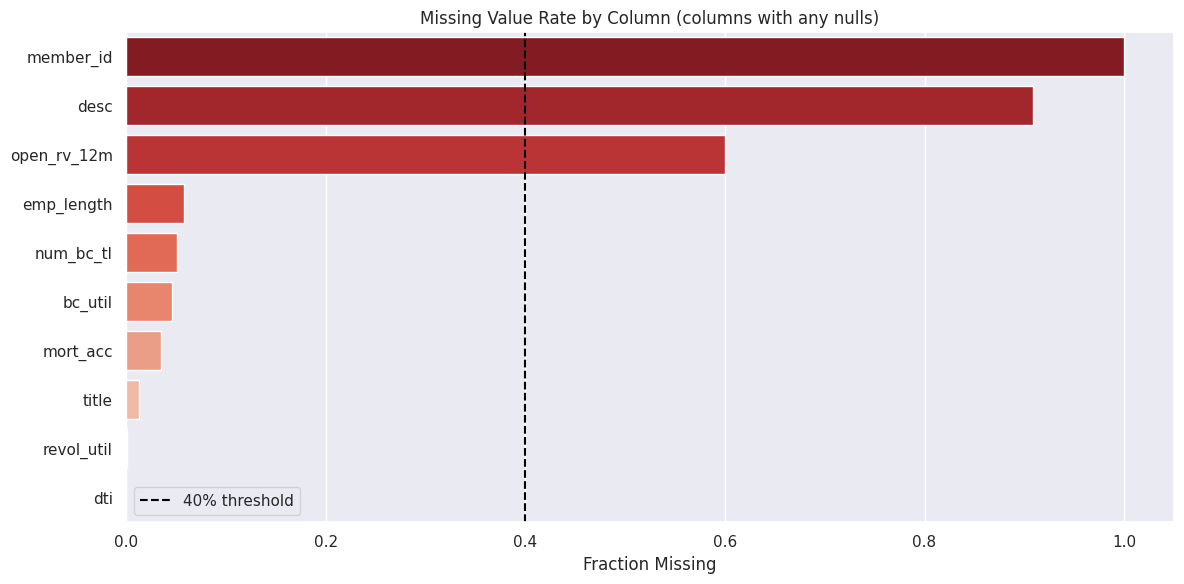

Columns above 40% null threshold: 3


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid')

# Plot missing value % for columns with any nulls
null_frac = df_raw.isnull().mean().sort_values(ascending=False)
null_frac = null_frac[null_frac > 0]

plt.figure(figsize=(12, 6))
plt.title('Missing Value Rate by Column (columns with any nulls)')
sns.barplot(x=null_frac.values, y=null_frac.index, palette='Reds_r')
plt.axvline(0.4, color='black', linestyle='--', label='40% threshold')
plt.xlabel('Fraction Missing')
plt.legend()
plt.tight_layout()
plt.savefig('/mnt/artifacts/results/missing_values.png', dpi=150)
plt.show()

print(f'Columns above 40% null threshold: {(null_frac > 0.4).sum()}')

## 3. Target Variable — Loan Default Rate

In [16]:
# Filter to resolved loans only
resolved = ['Fully Paid', 'Charged Off', 'Default']
df = df_raw[df_raw['loan_status'].isin(resolved)].copy()
df['is_default'] = df['loan_status'].isin(['Charged Off', 'Default']).astype(int)

print(f'Resolved loans : {len(df):,}')
print(f'Default rate   : {df["is_default"].mean():.2%}')
print(f'\nloan_status breakdown:')
print(df['loan_status'].value_counts())

Resolved loans : 50,000
Default rate   : 19.96%

loan_status breakdown:
loan_status
Fully Paid     40018
Charged Off     9981
Default            1
Name: count, dtype: int64


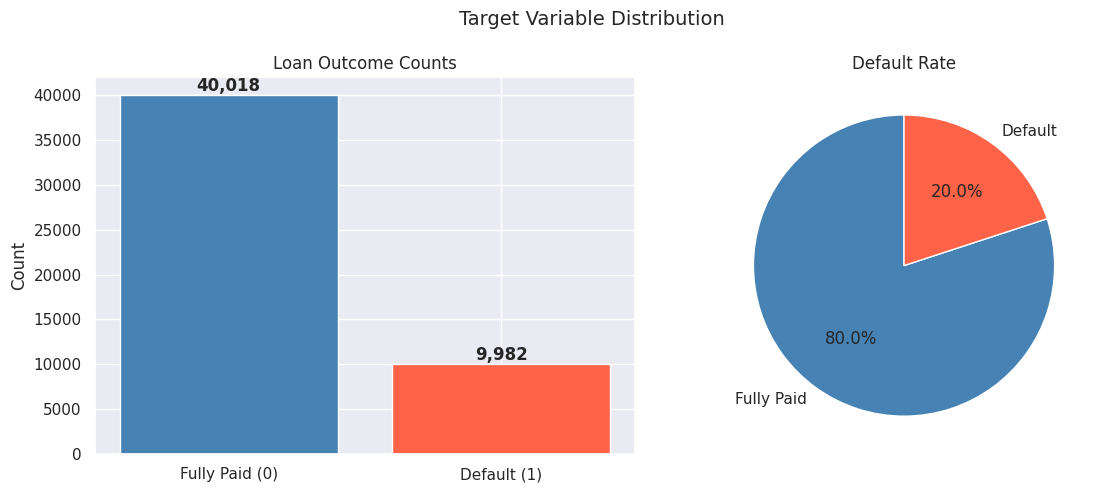

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable Distribution', fontsize=14)

# Count
counts = df['is_default'].value_counts()
axes[0].bar(['Fully Paid (0)', 'Default (1)'], counts.values,
            color=['steelblue', 'tomato'])
axes[0].set_title('Loan Outcome Counts')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie
axes[1].pie(counts.values, labels=['Fully Paid', 'Default'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Default Rate')

plt.tight_layout()
plt.savefig('/mnt/artifacts/results/target_distribution.png', dpi=150)
plt.show()

## 4. Key Feature Distributions

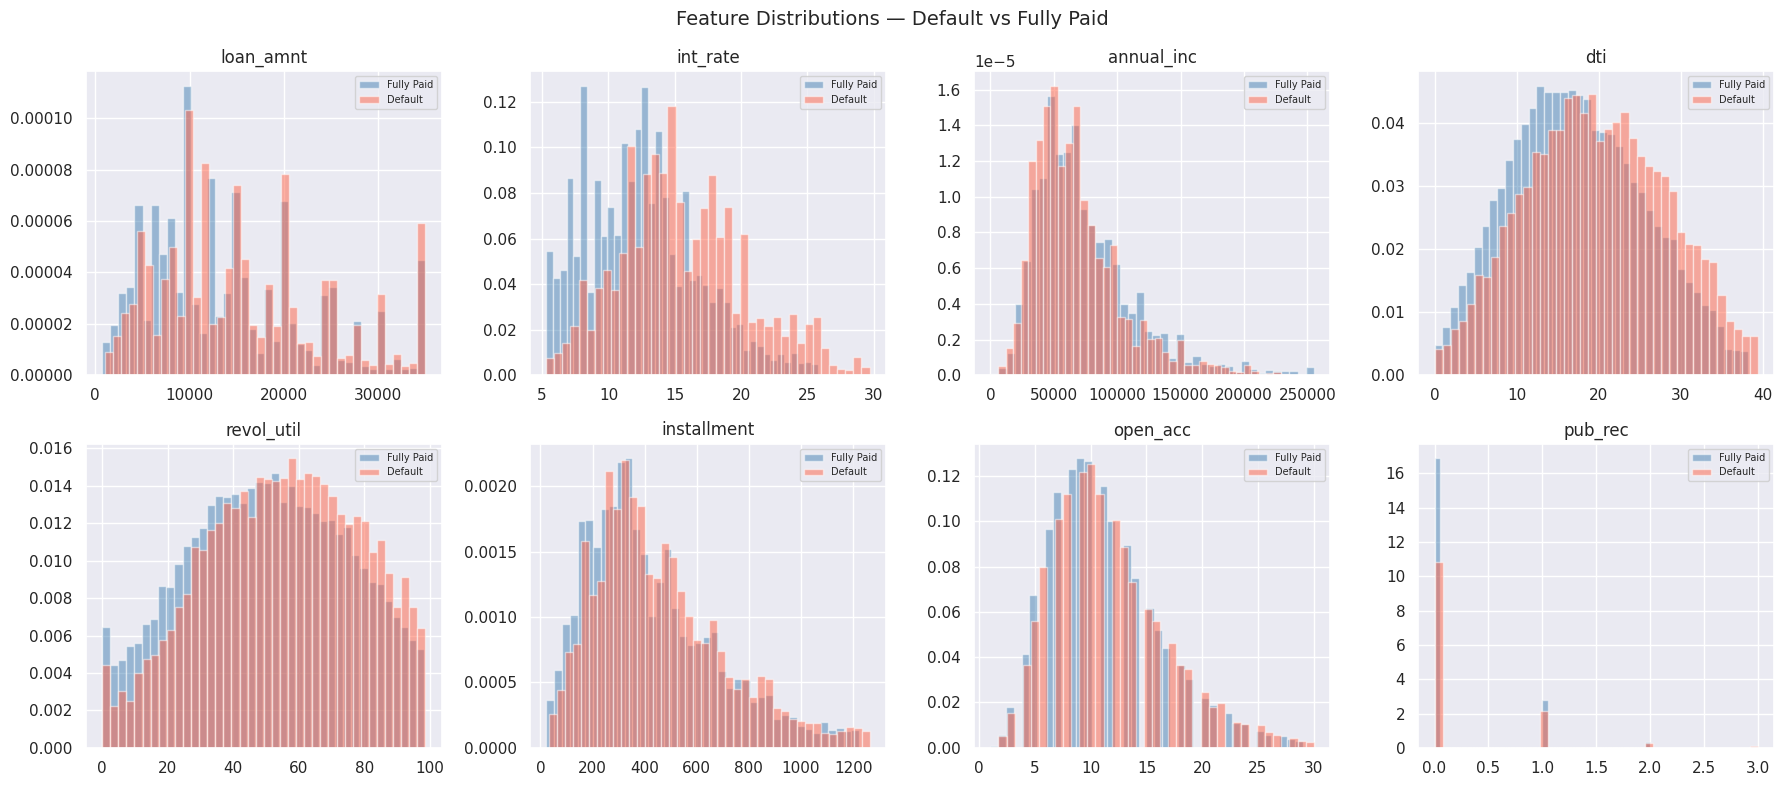

In [18]:
# Clean numeric columns
for col in ['int_rate', 'revol_util']:
    if df[col].dtype == object:
        df[col] = df[col].str.replace('%', '').astype(float)

numeric_feats = ['loan_amnt', 'int_rate', 'annual_inc', 'dti',
                 'revol_util', 'installment', 'open_acc', 'pub_rec']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Feature Distributions — Default vs Fully Paid', fontsize=14)
axes = axes.flatten()

for i, feat in enumerate(numeric_feats):
    for outcome, color, label in [(0, 'steelblue', 'Fully Paid'), (1, 'tomato', 'Default')]:
        subset = df[df['is_default'] == outcome][feat].dropna()
        # Cap extreme outliers for visualisation
        cap = subset.quantile(0.99)
        subset = subset[subset <= cap]
        axes[i].hist(subset, bins=40, alpha=0.5, color=color, label=label, density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.savefig('/mnt/artifacts/results/feature_distributions.png', dpi=150)
plt.show()

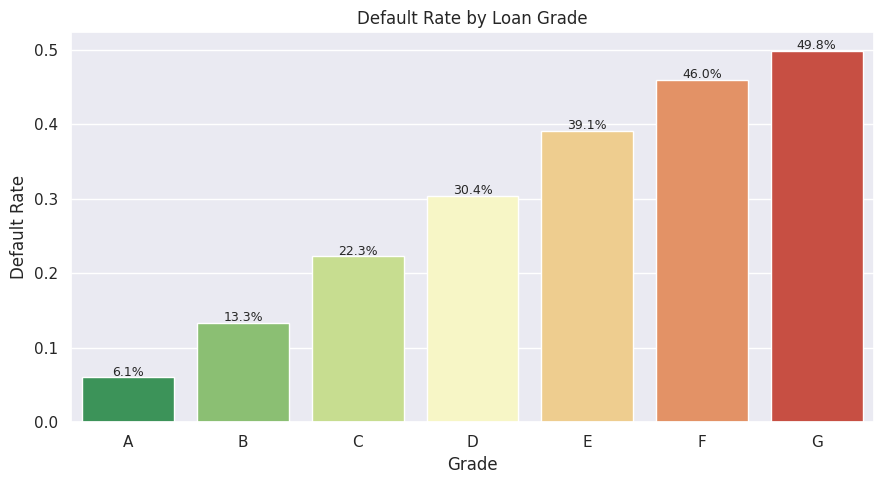

In [19]:
# Default rate by loan grade
grade_default = df.groupby('grade')['is_default'].mean().reset_index()
grade_default.columns = ['grade', 'default_rate']
grade_default = grade_default.sort_values('grade')

plt.figure(figsize=(9, 5))
plt.title('Default Rate by Loan Grade')
sns.barplot(data=grade_default, x='grade', y='default_rate',
            palette='RdYlGn_r')
plt.ylabel('Default Rate')
plt.xlabel('Grade')
for i, row in grade_default.reset_index().iterrows():
    plt.text(i, row['default_rate'] + 0.002, f"{row['default_rate']:.1%}",
             ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('/mnt/artifacts/results/default_by_grade.png', dpi=150)
plt.show()

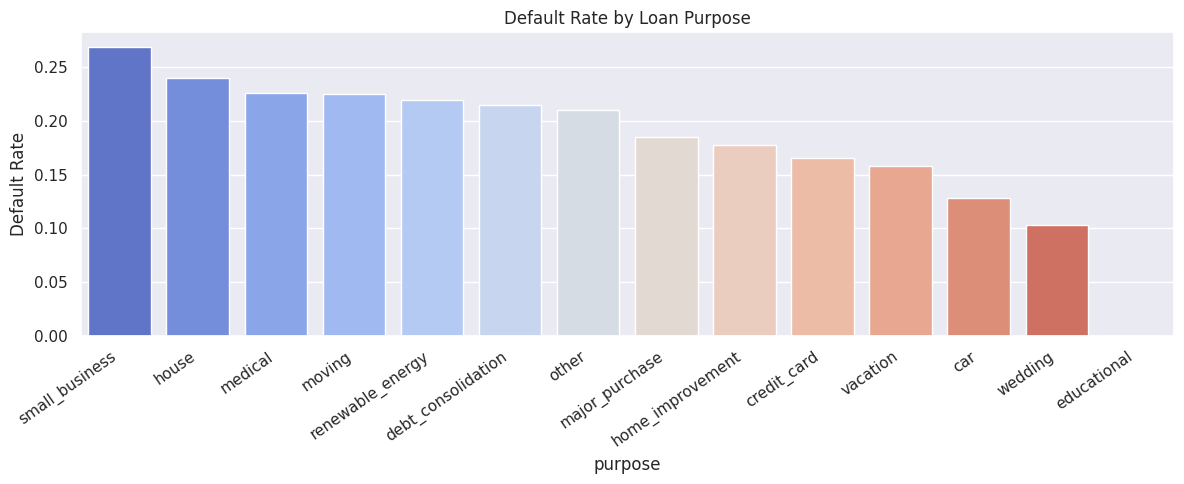

In [20]:
# Default rate by loan purpose
purpose_default = (
    df.groupby('purpose')['is_default']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'default_rate', 'count': 'n_loans'})
    .sort_values('default_rate', ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.title('Default Rate by Loan Purpose')
sns.barplot(data=purpose_default, x='purpose', y='default_rate', palette='coolwarm')
plt.xticks(rotation=35, ha='right')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.savefig('/mnt/artifacts/results/default_by_purpose.png', dpi=150)
plt.show()

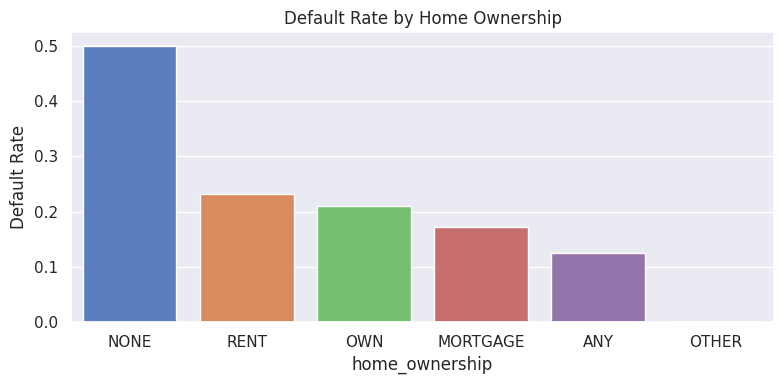

In [21]:
# Default rate by home ownership
ownership_default = (
    df.groupby('home_ownership')['is_default']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(8, 4))
plt.title('Default Rate by Home Ownership')
sns.barplot(data=ownership_default, x='home_ownership', y='is_default', palette='muted')
plt.ylabel('Default Rate')
plt.tight_layout()
plt.savefig('/mnt/artifacts/results/default_by_ownership.png', dpi=150)
plt.show()

## 5. Correlation Analysis

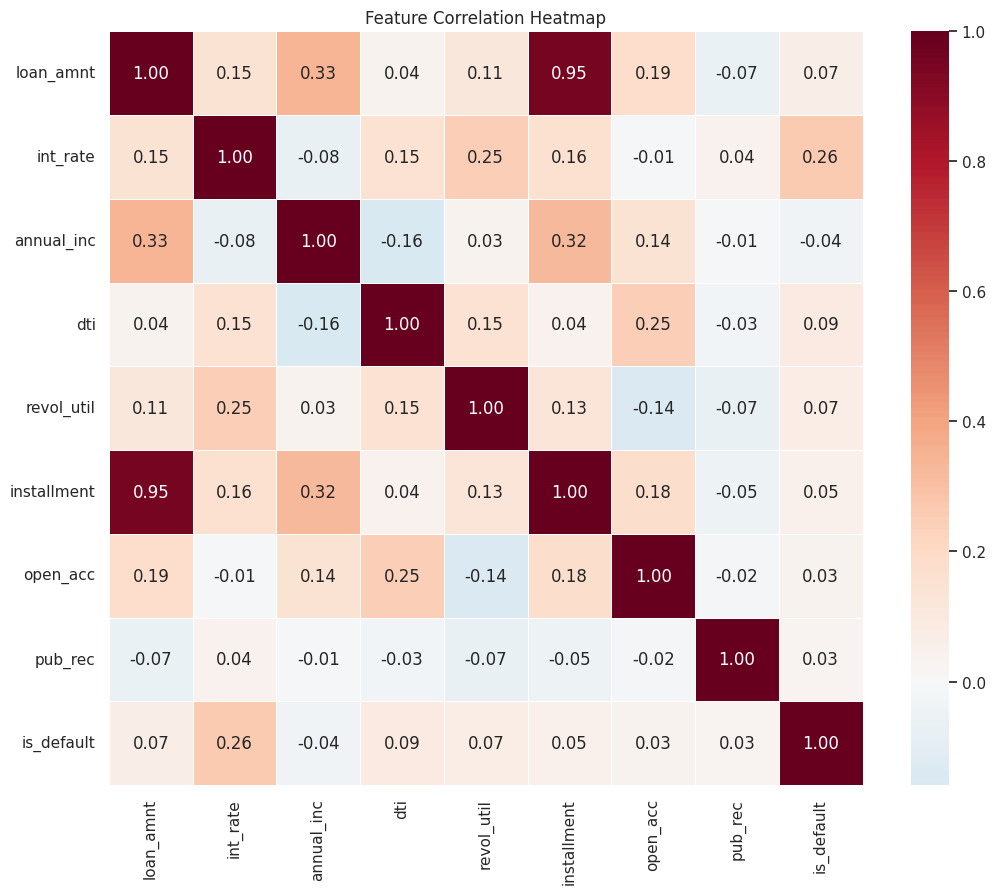

In [22]:
corr_cols = numeric_feats + ['is_default']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(11, 9))
plt.title('Feature Correlation Heatmap')
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.tight_layout()
plt.savefig('/mnt/artifacts/results/correlation_heatmap.png', dpi=150)
plt.show()

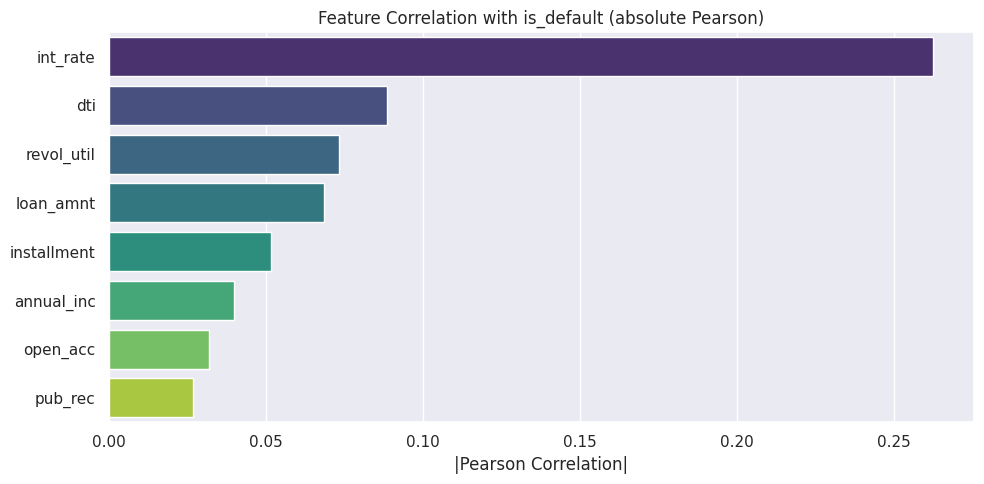

Top features correlated with default:
int_rate       0.262425
dti            0.088553
revol_util     0.073368
loan_amnt      0.068556
installment    0.051774
annual_inc     0.039966
open_acc       0.031770
pub_rec        0.026777
Name: is_default, dtype: float64


In [23]:
# Feature importance by absolute correlation with target
target_corr = corr_matrix['is_default'].drop('is_default').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.title('Feature Correlation with is_default (absolute Pearson)')
sns.barplot(x=target_corr.values, y=target_corr.index, palette='viridis')
plt.xlabel('|Pearson Correlation|')
plt.tight_layout()
plt.savefig('/mnt/artifacts/results/feature_importance_corr.png', dpi=150)
plt.show()

print('Top features correlated with default:')
print(target_corr.head(10))

## 6. Run Preprocessing Pipeline

In [24]:
import sys
sys.path.append('..')
from scripts.preprocess import run_pipeline
import os

#project = os.environ.get('DOMINO_PROJECT_NAME', 'LendingClubProject')
project = os.environ.get('DOMINO_PROJECT_NAME', 'domino-training-lending-club')


raw_path     = f'/domino/datasets/local/{project}/lending_raw.csv'
cleaned_path = f'/domino/datasets/local/{project}/lending_clean.csv'

raw_path     = f'/mnt/data/{project}/lending_raw.csv'
cleaned_path = f'/mnt/data/{project}/lending_clean.csv'

df_clean = run_pipeline(raw_path, cleaned_path)
df_clean.head()

2026-04-10 16:24:23,869 [INFO] Loading raw data from: /mnt/data/domino-training-lending-club/lending_raw.csv
2026-04-10 16:24:24,063 [INFO] Loaded 50,000 rows, 36 columns
2026-04-10 16:24:24,085 [INFO] Dropping 3 columns with >40% nulls: ['open_rv_12m', 'member_id', 'desc']
2026-04-10 16:24:24,100 [INFO] Filtered to resolved loans: 50,000 → 50,000 rows
2026-04-10 16:24:24,104 [INFO] Target created — default rate: 19.96%
2026-04-10 16:24:24,121 [INFO] Engineering new features...
2026-04-10 16:24:24,137 [INFO] Feature engineering complete
2026-04-10 16:24:24,138 [INFO] One-hot encoding: ['grade', 'home_ownership', 'purpose', 'term', 'verification_status']
2026-04-10 16:24:24,186 [INFO] Dropping redundant columns: ['loan_status', 'sub_grade', 'title', 'zip_code', 'addr_state', 'earliest_cr_line', 'issue_d', 'url', 'id', 'policy_code']
2026-04-10 16:24:24,202 [INFO] Dropped rows with remaining nulls: 50,000 → 44,181
2026-04-10 16:24:24,915 [INFO] Cleaned dataset saved to: /mnt/data/domino-

,loan_amnt,int_rate,installment,annual_inc,emp_length,dti,revol_bal,revol_util,open_acc,total_acc,...,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,term_60,verification_status_Source Verified,verification_status_Verified
1,24950.0,19.99,660.89,65000.0,< 1 year,19.46,34511.0,98.0,5.0,12.0,...,0,0,0,0,0,0,0,1,0,1
2,3500.0,7.21,108.41,45000.0,5 years,28.37,11831.0,53.0,12.0,16.0,...,0,0,0,0,0,0,0,0,0,0
3,17000.0,21.49,464.61,60000.0,1 year,9.86,15235.0,81.5,8.0,16.0,...,0,0,0,0,0,0,0,1,1,0
4,15000.0,17.10,373.60,56000.0,10+ years,20.38,14631.0,61.7,16.0,24.0,...,0,0,0,0,0,0,0,1,0,1
5,10000.0,13.99,232.64,59000.0,3 years,10.64,15005.0,43.6,10.0,14.0,...,0,0,0,0,0,0,0,1,1,0


In [25]:
print(f'Cleaned shape   : {df_clean.shape}')
print(f'Default rate    : {df_clean["is_default"].mean():.2%}')
print(f'\nSample columns  : {list(df_clean.columns[:20])}')
df_clean.describe().T

Cleaned shape   : (44181, 52)
Default rate    : 19.78%

Sample columns  : ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'emp_length', 'dti', 'revol_bal', 'revol_util', 'open_acc', 'total_acc', 'pub_rec', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mort_acc', 'bc_util', 'num_bc_tl', 'is_default', 'loan_to_income']


,count,mean,std,min,25%,50%,75%,max
loan_amnt,44181.0,14816.685340,8797.928134,1000.000000,8000.000000,12800.000000,20000.000000,4.000000e+04
int_rate,44181.0,13.248862,4.804114,5.310000,9.710000,12.740000,16.010000,3.099000e+01
installment,44181.0,450.084453,265.110116,28.820000,257.850000,385.620000,597.780000,1.533810e+03
annual_inc,44181.0,78628.255456,63036.029657,600.000000,48000.000000,66352.000000,95000.000000,6.500000e+06
dti,44181.0,18.333663,9.112264,0.000000,11.940000,17.690000,24.220000,4.669200e+02
revol_bal,44181.0,16715.109866,24150.964659,0.000000,6168.000000,11394.000000,20067.000000,1.298783e+06
revol_util,44181.0,52.018687,24.303557,0.000000,33.700000,52.100000,70.800000,1.345000e+02
open_acc,44181.0,11.832394,5.573152,1.000000,8.000000,11.000000,15.000000,6.300000e+01
total_acc,44181.0,25.245898,12.146047,2.000000,16.000000,24.000000,32.000000,1.210000e+02
pub_rec,44181.0,0.219302,0.670266,0.000000,0.000000,0.000000,0.000000,6.100000e+01


## 7. Verify Engineered Features

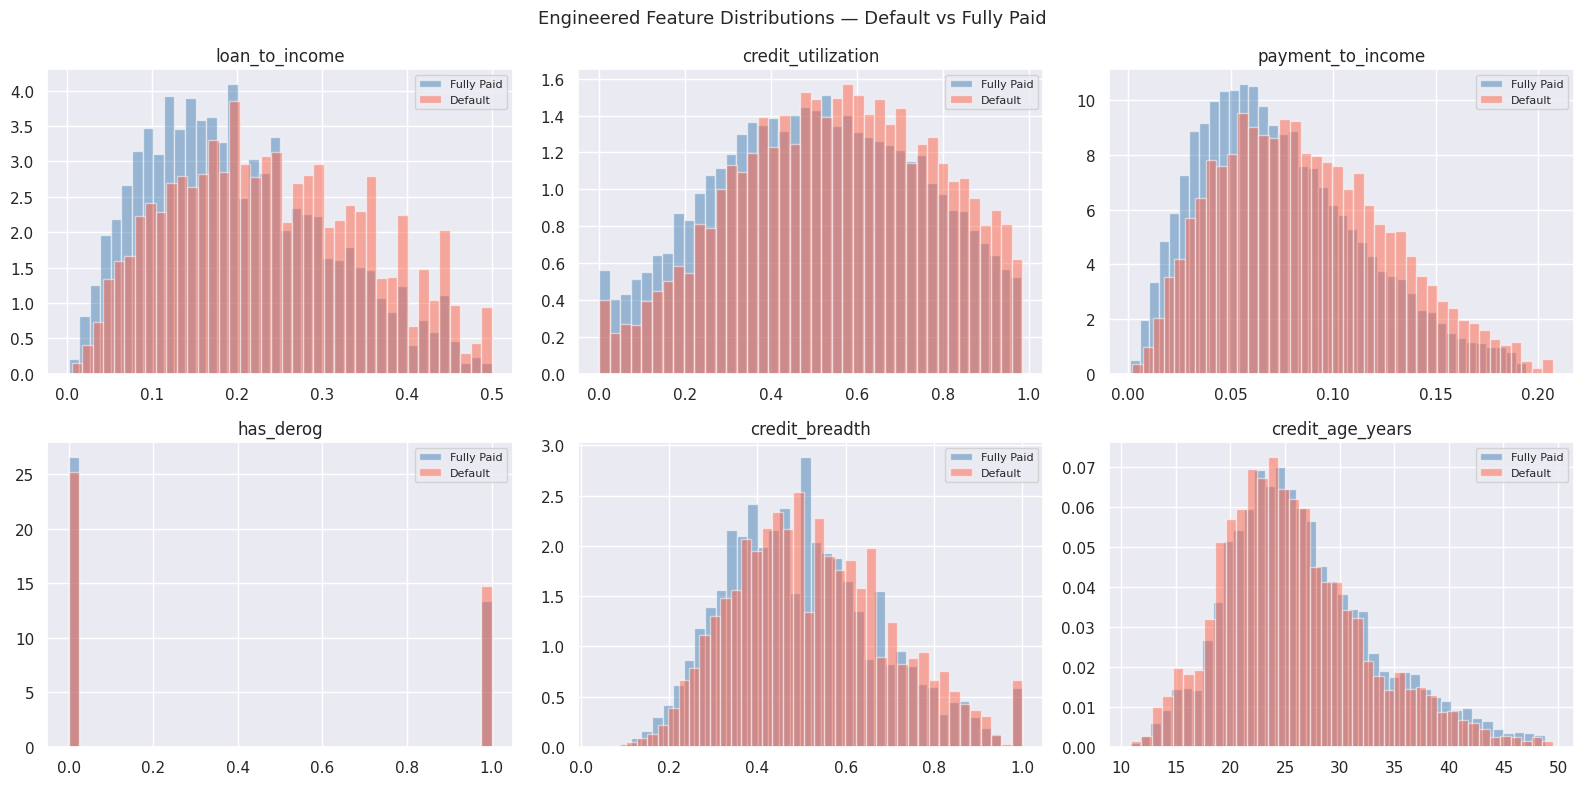

In [26]:
engineered = ['loan_to_income', 'credit_utilization', 'payment_to_income',
              'has_derog', 'credit_breadth', 'credit_age_years']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Engineered Feature Distributions — Default vs Fully Paid', fontsize=13)
axes = axes.flatten()

for i, feat in enumerate(engineered):
    if feat not in df_clean.columns:
        axes[i].set_title(f'{feat} (not found)')
        continue
    for outcome, color, label in [(0, 'steelblue', 'Fully Paid'), (1, 'tomato', 'Default')]:
        subset = df_clean[df_clean['is_default'] == outcome][feat].dropna()
        cap = subset.quantile(0.99)
        subset = subset[subset <= cap]
        axes[i].hist(subset, bins=40, alpha=0.5, color=color, label=label, density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('/mnt/artifacts/results/engineered_features.png', dpi=150)
plt.show()

---
## Summary

Key findings from this EDA:

- **Default rate** is approximately 20-25% across resolved loans — a moderately imbalanced classification problem
- **Interest rate** and **grade** are strong predictors — higher grade (E/F/G) loans default significantly more
- **DTI** (debt-to-income) shows a clear separation between defaulted and fully paid loans
- **Small business** loans have the highest default rate by purpose; **credit card** the lowest
- Engineered features (`loan_to_income`, `credit_utilization`) show meaningful separation between classes

The cleaned dataset is ready for model training. Proceed to `scripts/multitrain.py`.